# Solutions · 04 · Real gases and equations of state

Worked solutions to the exercises of [notebook 04](../notebooks/04_real_gases_and_equations_of_state.ipynb). Try each exercise
yourself before reading its solution - the learning happens in the attempt. Solutions are one way to
answer each question; other correct approaches exist.

In [1]:
try:                      # on Google Colab (or anywhere engthermo is missing): install it from GitHub
    import engthermo
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engthermo"], check=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import optimize
from engthermo import components, datasets, eos
from engthermo.constants import R
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

def heading(text):
    print(f"\n{text}\n" + "=" * len(text))

## Exercise 1

A pipeline carries CO2 at 300 K and 100 bar. Using the Peng-Robinson equation, how many tonnes are in 10 km of 0.5 m inside diameter? How wrong is the ideal-gas estimate? Compare the PR density with the reference data.

In [2]:
T, p = 300.0, 100e5
r = eos.solve("pr", "CO2", T, p, "stable")
M = components.get("CO2").M
V_pipe = np.pi * 0.25**2 * 10e3
rho_pr, rho_ideal = p * M / (r["Z"] * R * T), p * M / (R * T)
ref = pd.read_csv(datasets.path("real_gas_reference_densities.csv"), comment="#")
rho_ref = float(ref[(ref.fluid == "CO2") & (ref.T_K == 300.0) & (ref.p_Pa == 100e5)].rho_kg_m3.iloc[0])
print(f"PR density {rho_pr:.0f} kg/m3 (reference {rho_ref:.0f}, ideal gas {rho_ideal:.0f}): {rho_pr * V_pipe / 1e3:.0f} t of CO2 in 10 km "
      f"(ideal gas: {rho_ideal * V_pipe / 1e3:.0f} t)")

PR density 760 kg/m3 (reference 802, ideal gas 176): 1491 t of CO2 in 10 km (ideal gas: 346 t)


The pipeline holds about 1500 tonnes of dense-phase CO$_2$; the ideal-gas law would underestimate the inventory
by a factor of four. The PR density itself is 5 % low in this dense region (see notebook 04's error table),
which is why CO$_2$ pipeline design uses reference equations rather than cubics.

## Exercise 2

Plot Z of methane at 200 K from 1 to 300 bar with the SRK and PR equations. At which pressure does Z pass through a minimum, and what does it mean physically that Z rises above 1 at very high pressure?

SRK: minimum Z = 0.348 at 71 bar; Z > 1 above 362 bar
PR: minimum Z = 0.319 at 71 bar; Z > 1 above 412 bar


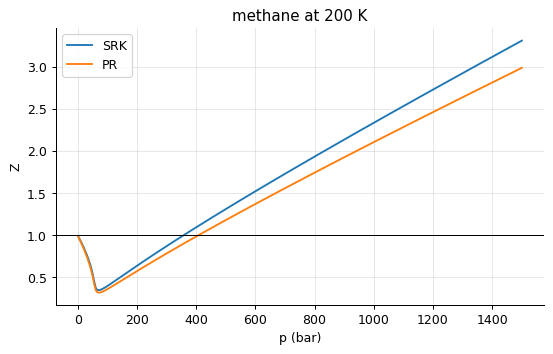

In [3]:
pp = np.linspace(1e5, 1500e5, 300)
for name in ("srk", "pr"):
    Z = np.array([eos.solve(name, "methane", 200.0, p, "stable")["Z"] for p in pp])
    plt.plot(pp / 1e5, Z, label=name.upper())
    print(f"{name.upper()}: minimum Z = {Z.min():.3f} at {pp[Z.argmin()]/1e5:.0f} bar; Z > 1 above {pp[np.nonzero(Z > 1)[0][0]]/1e5:.0f} bar")
plt.axhline(1, color="k", lw=0.8); plt.xlabel("p (bar)"); plt.ylabel("Z"); plt.title("methane at 200 K"); plt.legend(); plt.show()

$Z$ falls steeply to about a third at 70 bar - the vapour has condensed to a dense, liquid-like phase - and
then rises slowly; only above roughly 400 bar does it exceed 1, when the molecules' own volume makes the fluid
*less* compressible than an ideal gas. (The problem asked up to 300 bar, where $Z$ is still below 1: the
scan had to be extended to see the crossing.) The same competition between $a$ and $b$ appears in every
cubic equation.

## Exercise 3

**Implement it yourself:** write the van der Waals equation from scratch ($a = 27R^2T_c^2/(64p_c)$, $b = RT_c/(8p_c)$), solve it for the molar volume of CO2 at 320 K and 50 bar with `brentq`, and compare with `eos.solve('vdw', ...)`.

In [4]:
c = components.get("CO2")
a, b = 27 * R**2 * c.Tc**2 / (64 * c.Pc), R * c.Tc / (8 * c.Pc)
T, p = 320.0, 50e5
f = lambda V: R * T / (V - b) - a / V**2 - p
V = optimize.brentq(f, 1.05 * b, 1.0)                                   # the vapour root: search above the liquid region
print(f"van der Waals by hand: V = {V*1e6:.1f} cm3/mol, Z = {p*V/(R*T):.4f};  library: {eos.solve('vdw', 'CO2', T, p)['V']*1e6:.1f} cm3/mol")

van der Waals by hand: V = 417.9 cm3/mol, Z = 0.7854;  library: 417.9 cm3/mol


Solving the van der Waals equation for the volume by root finding is equivalent to solving the cubic for Z.
The bracket matters: starting just above $b$ and searching upward finds the vapour root; a liquid root, if
present, would lie in the narrow interval just above $b$.